In [23]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import interact

# =====================================================================
# 1. LOAD AND PREP DATA
# =====================================================================
# Read the provided CSV files
df_cb = pd.read_csv("cross_border_payments.csv")
df_tf = pd.read_csv("trade_finance.csv")
df_tb = pd.read_csv("transactional_banking.csv")

# Standardize transaction types so they can be seamlessly combined
df_cb['transaction_type'] = 'cross_border'
df_tf['transaction_type'] = df_tf['instrument_type']

# Combine datasets
cols_to_keep = ['entity_name', 'beneficiary_name', 'date', 'direction', 'value_zar', 'transaction_type']
df_combined = pd.concat([df_cb[cols_to_keep], df_tf[cols_to_keep]])

# Map Source and Target logically based on the direction of funds
def get_source_target(row):
    # Outbound money flows from the Client (entity) to the Counterparty (beneficiary)
    if row['direction'] in ['outbound', 'export']:
        return pd.Series([row['entity_name'], row['beneficiary_name']])
    # Inbound money flows from the Counterparty (beneficiary) to the Client (entity)
    else:
        return pd.Series([row['beneficiary_name'], row['entity_name']])

df_combined[['source', 'target']] = df_combined.apply(get_source_target, axis=1)

# Group by Date, Source, and Target to sum the total edge weights (strength) for that day
df_edges = df_combined.groupby(['date', 'source', 'target'])['value_zar'].sum().reset_index()

# Get unique sorted dates and a list of all unique entities for the dropdown menus
available_dates = sorted(df_edges['date'].unique())
all_entities = sorted(pd.concat([df_edges['source'], df_edges['target']]).unique())

# =====================================================================
# 2. PLOTTING FUNCTION (The Ego-Graph with Curved Edges)
# =====================================================================
def plot_company_network(company_name, target_date):
    """Filters the data for the selected company and date, then draws the ego-graph."""
    
    # Filter for the specific date
    df_day = df_edges[df_edges['date'] == target_date]
    
    # Filter for edges where the selected company is either sending OR receiving money
    df_company = df_day[(df_day['source'] == company_name) | (df_day['target'] == company_name)]
    
    if df_company.empty:
        print(f"No transactions found for {company_name} on {target_date}.")
        return
    
    # Build the directed graph
    G = nx.from_pandas_edgelist(
        df_company, 
        source='source', 
        target='target', 
        edge_attr='value_zar', 
        create_using=nx.DiGraph()
    )
    
    # Plot setup
    plt.figure(figsize=(12, 8), facecolor='white')
    plt.title(f"Transaction Network for {company_name}\nDate: {target_date}", fontsize=16, pad=20)
    
    # Use a spring layout for clean visual spacing
    pos = nx.spring_layout(G, k=0.5, seed=42)
    
    # Differentiate the central "Ego" node from the counterparties
    node_colors = ['#ff4b4b' if node == company_name else '#4b8bbe' for node in G.nodes()]
    node_sizes = [3000 if node == company_name else 1000 for node in G.nodes()]
    
    # Draw Nodes
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes, edgecolors='black')
    
    # Calculate edge thickness based on transaction size relative to the day's maximum
    weights = [G[u][v]['value_zar'] for u, v in G.edges()]
    max_weight = max(weights) if weights else 1
    edge_widths = [(w / max_weight) * 5 + 1 for w in weights]
    
    # Draw Edges - arc3 adds the curve to ensure inbound and outbound flows don't overlap
    nx.draw_networkx_edges(
        G, pos, 
        arrowstyle='->', 
        arrowsize=20, 
        width=edge_widths, 
        edge_color='gray', 
        alpha=0.7,
        connectionstyle="arc3, rad=0.2"
    )
    
    # Draw Node Labels
    nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')
    
    # Add Edge Labels (Transaction amounts formatted in Millions)
    edge_labels = { (u, v): f"R {d['value_zar']/1e6:.1f}m" for u, v, d in G.edges(data=True) }
    
    # label_pos shifts the text slightly to avoid colliding with opposite-direction labels
    nx.draw_networkx_edge_labels(
        G, pos, 
        edge_labels=edge_labels, 
        font_size=9, 
        font_color='darkred',
        label_pos=0.3
    )
    
    plt.axis('off')
    plt.tight_layout()
    plt.show()

# =====================================================================
# 3. INTERACTIVE DROPDOWNS (Requires Jupyter Notebook)
# =====================================================================
# interact(
#     plot_company_network, 
#     company_name=widgets.Dropdown(options=all_entities, value=all_entities[0], description='Company:'),
#     target_date=widgets.Dropdown(options=available_dates, value=available_dates[0], description='Date:')
# );

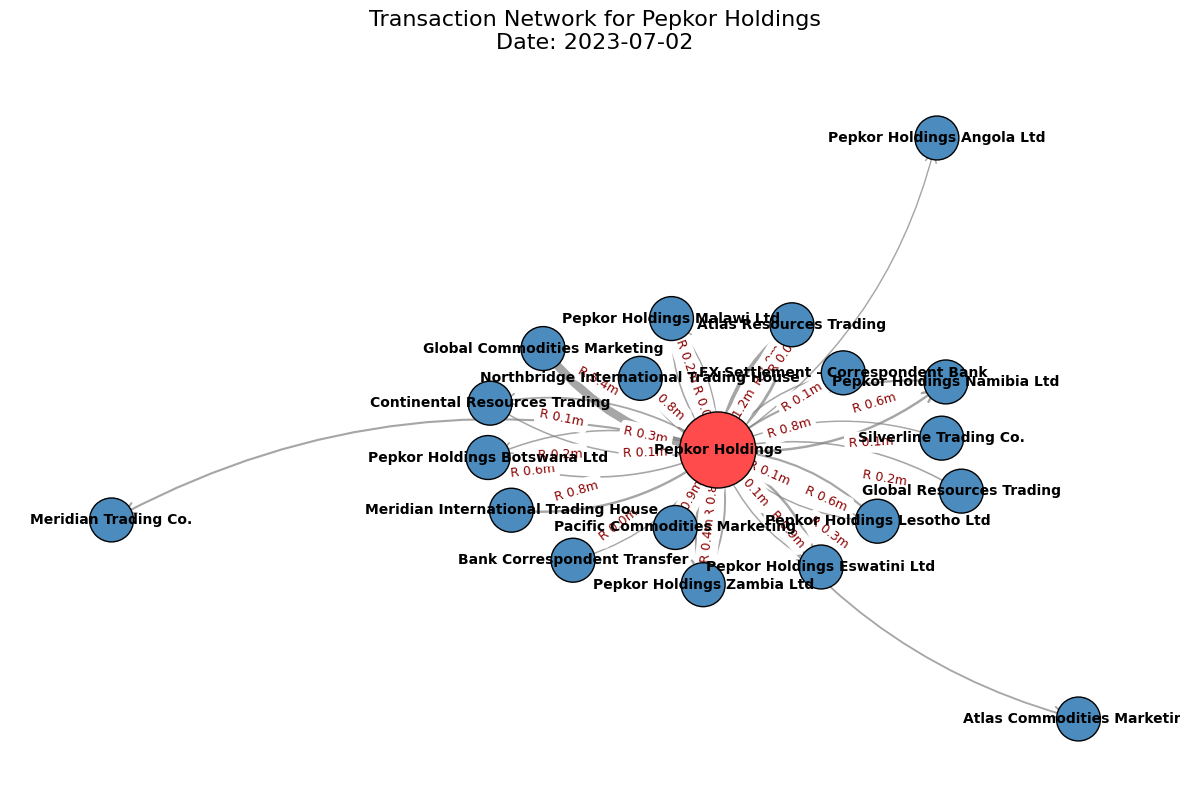

In [25]:
########### DEPENDENCE PLOT
plot_company_network(company_name="Pepkor Holdings", target_date="2023-07-02")

In [1]:
import os
import pandas as pd
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import interact
from matplotlib.ticker import FuncFormatter

# =====================================================================
# 1. LOAD AND PREP DATA (Daily Granularity)
# =====================================================================
datasets = []

# Helper function to standardize the column name
def standardize_amount_col(df):
    if 'amount_zar' in df.columns:
        return df.rename(columns={'amount_zar': 'value_zar'})
    return df

if os.path.exists("cross_border_payments.csv"):
    df_cb = pd.read_csv("cross_border_payments.csv")
    df_cb = standardize_amount_col(df_cb)
    df_cb['transaction_type'] = 'cross_border'
    datasets.append(df_cb)

if os.path.exists("trade_finance.csv"):
    df_tf = pd.read_csv("trade_finance.csv")
    df_tf = standardize_amount_col(df_tf)
    df_tf['transaction_type'] = df_tf['instrument_type']
    datasets.append(df_tf)

if os.path.exists("transactional_banking.csv"):
    df_tb = pd.read_csv("transactional_banking.csv")
    df_tb = standardize_amount_col(df_tb)
    df_tb['transaction_type'] = 'transactional'
    datasets.append(df_tb)

# Combine all datasets safely
cols_to_keep = ['entity_name', 'beneficiary_name', 'date', 'direction', 'value_zar', 'transaction_type']
df_combined = pd.concat([df[cols_to_keep] for df in datasets], ignore_index=True)

# Map Source and Target based on direction of funds
def get_source_target(row):
    if row['direction'] in ['outbound', 'export']:
        return pd.Series([row['entity_name'], row['beneficiary_name']])
    else:
        return pd.Series([row['beneficiary_name'], row['entity_name']])

df_combined[['source', 'target']] = df_combined.apply(get_source_target, axis=1)

# Normalize date format
df_combined['date'] = pd.to_datetime(df_combined['date']).dt.strftime('%Y-%m-%d')

# Group by exact Date, Source, and Target
df_edges = df_combined.groupby(['date', 'source', 'target'])['value_zar'].sum().reset_index()

available_dates = sorted(df_edges['date'].unique())
all_entities = sorted(pd.concat([df_edges['source'], df_edges['target']]).unique())

# =====================================================================
# 2. BUILD DAILY TEMPORAL GRAPHS
# =====================================================================
daily_graphs = {}
for d in available_dates:
    df_d = df_edges[df_edges['date'] == d]
    G = nx.DiGraph(date=d)
    for _, row in df_d.iterrows():
        G.add_edge(row['source'], row['target'], weight=row['value_zar'])
    daily_graphs[d] = G

# =====================================================================
# 3. MACRO-LEVEL DAILY ANALYSIS ENGINE
# =====================================================================
def compute_macro_metrics(graphs):
    stats = []
    for d, G in graphs.items():
        total_vol = sum(d_attr['weight'] for u, v, d_attr in G.edges(data=True))
        density = nx.density(G)
        
        node_vols = {n: sum(d_attr['weight'] for u, v, d_attr in G.in_edges(n, data=True)) + 
                        sum(d_attr['weight'] for u, v, d_attr in G.out_edges(n, data=True)) for n in G.nodes()}
        total_node_vol = sum(node_vols.values())
        
        hhi = 0
        if total_node_vol > 0:
            shares = [(v / total_node_vol) * 100 for v in node_vols.values()]
            hhi = sum(s**2 for s in shares)
            
        stats.append({
            'date': d,
            'Total_Volume': total_vol,
            'Density': density,
            'HHI_Concentration': hhi
        })
    return pd.DataFrame(stats)

df_macro = compute_macro_metrics(daily_graphs)

# =====================================================================
# 4. MICRO/MESO-LEVEL DAILY COMPANY ANALYTICS
# =====================================================================
def analyze_company_daily_metrics(company_name):
    stats = []
    prev_vol = None
    
    for d in available_dates:
        G = daily_graphs[d]
        if company_name in G:
            in_vol = sum(d_attr['weight'] for u, v, d_attr in G.in_edges(company_name, data=True))
            out_vol = sum(d_attr['weight'] for u, v, d_attr in G.out_edges(company_name, data=True))
            total_vol = in_vol + out_vol
            
            velocity = ((total_vol - prev_vol) / prev_vol * 100) if prev_vol and prev_vol > 0 else 0
            prev_vol = total_vol
            
            clustering = nx.clustering(G.to_undirected(), company_name)
            
            stats.append({
                'date': d,
                'In_Volume': in_vol,
                'Out_Volume': out_vol,
                'Total_Volume': total_vol,
                'Velocity_%': velocity,
                'Local_Clustering': clustering
            })
        else:
            prev_vol = None
            stats.append({
                'date': d, 'In_Volume': 0, 'Out_Volume': 0, 'Total_Volume': 0, 
                'Velocity_%': 0, 'Local_Clustering': 0
            })
            
    return pd.DataFrame(stats)

# =====================================================================
# 5. DUAL-VIEW INTERACTIVE DASHBOARD (Ego-Graph + Daily Analytics)
# =====================================================================
def format_millions(x, pos):
    return f'R{x*1e-6:.0f}m'

def display_daily_network_dashboard(company_name, target_date):
    # --- PART A: Draw Ego-Graph for Selected Date ---
    df_day = df_edges[df_edges['date'] == target_date]
    df_company = df_day[(df_day['source'] == company_name) | (df_day['target'] == company_name)]
    
    plt.figure(figsize=(16, 12), facecolor='white')
    
    # Subplot 1: Ego Network Graph with Curved Edges
    plt.subplot(2, 1, 1)
    if not df_company.empty:
        G_ego = nx.from_pandas_edgelist(
            df_company, source='source', target='target', 
            edge_attr='value_zar', create_using=nx.DiGraph()
        )
        pos = nx.spring_layout(G_ego, k=0.5, seed=42)
        node_colors = ['#ff4b4b' if node == company_name else '#4b8bbe' for node in G_ego.nodes()]
        node_sizes = [3000 if node == company_name else 1000 for node in G_ego.nodes()]
        
        nx.draw_networkx_nodes(G_ego, pos, node_color=node_colors, node_size=node_sizes, edgecolors='black')
        
        weights = [G_ego[u][v]['value_zar'] for u, v in G_ego.edges()]
        max_weight = max(weights) if weights else 1
        edge_widths = [(w / max_weight) * 5 + 1 for w in weights]
        
        nx.draw_networkx_edges(
            G_ego, pos, arrowstyle='->', arrowsize=20, width=edge_widths, 
            edge_color='gray', alpha=0.7, connectionstyle="arc3, rad=0.2"
        )
        nx.draw_networkx_labels(G_ego, pos, font_size=10, font_weight='bold')
        edge_labels = { (u, v): f"R {d['value_zar']/1e6:.1f}m" for u, v, d in G_ego.edges(data=True) }
        nx.draw_networkx_edge_labels(G_ego, pos, edge_labels=edge_labels, font_size=9, font_color='darkred', label_pos=0.3)
        plt.title(f"Ego Network for {company_name} on {target_date} (Curved Edges show 2-way flows)", fontsize=14, weight='bold')
    else:
        plt.text(0.5, 0.5, f"No transactions found for {company_name} on {target_date}.", 
                 horizontalalignment='center', verticalalignment='center', fontsize=12)
        plt.title(f"Ego Network for {company_name} on {target_date}", fontsize=14, weight='bold')
    plt.axis('off')
    
    # --- PART B: Time-Series Trend Analytics Subplots ---
    df_micro = analyze_company_metrics_daily_helper = analyze_company_daily_metrics(company_name)
    
    fig_tr, axs = plt.subplots(1, 3, figsize=(18, 5), facecolor='#f8f9fa')
    
    # 1. Daily Inbound vs Outbound Flow
    axs[0].plot(df_micro['date'], df_micro['In_Volume'], label='Inbound', color='green', marker='o', markersize=3)
    axs[0].plot(df_micro['date'], df_micro['Out_Volume'], label='Outbound', color='red', marker='x', markersize=3)
    axs[0].set_title(f'{company_name}: Daily Flow', weight='bold')
    axs[0].yaxis.set_major_formatter(FuncFormatter(format_millions))
    axs[0].tick_params(axis='x', rotation=45)
    axs[0].legend()
    axs[0].grid(True, linestyle='--', alpha=0.6)
    
    # 2. Daily Velocity (Day-over-Day Growth)
    axs[1].bar(df_micro['date'], df_micro['Velocity_%'], color=np.where(df_micro['Velocity_%'] > 0, 'green', 'red'), width=1.0)
    axs[1].set_title(f'{company_name}: Daily Velocity (%)', weight='bold')
    axs[1].axhline(0, color='black', linewidth=1)
    axs[1].tick_params(axis='x', rotation=45)
    
    # 3. Macro System Liquidity
    axs[2].plot(df_macro['date'], df_macro['Total_Volume'], color='purple', linewidth=2)
    axs[2].set_title('Macro: Total System Liquidity', weight='bold')
    axs[2].yaxis.set_major_formatter(FuncFormatter(format_millions))
    axs[2].tick_params(axis='x', rotation=45)
    axs[2].grid(True, linestyle='--', alpha=0.6)
    
    plt.tight_layout()
    plt.show()

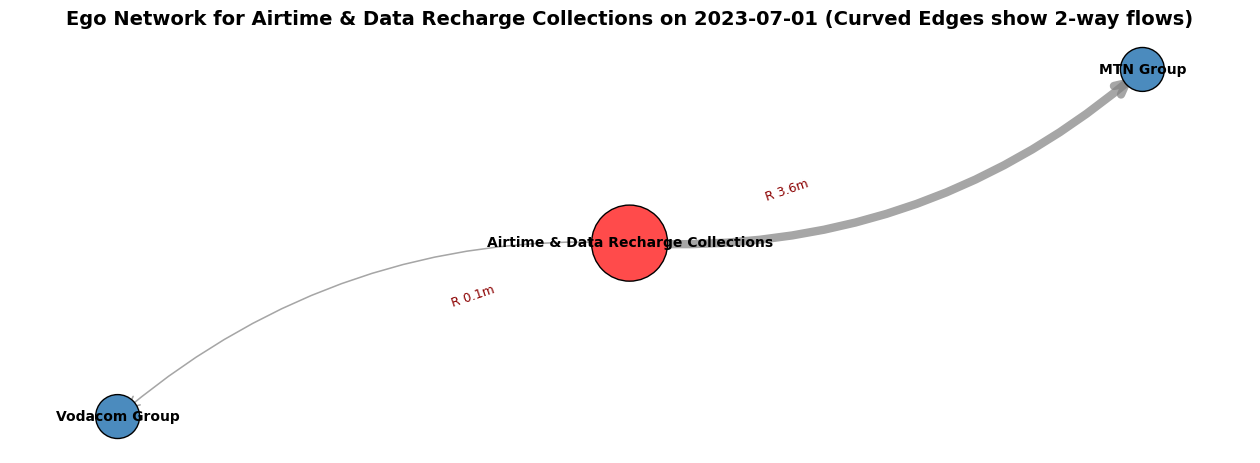

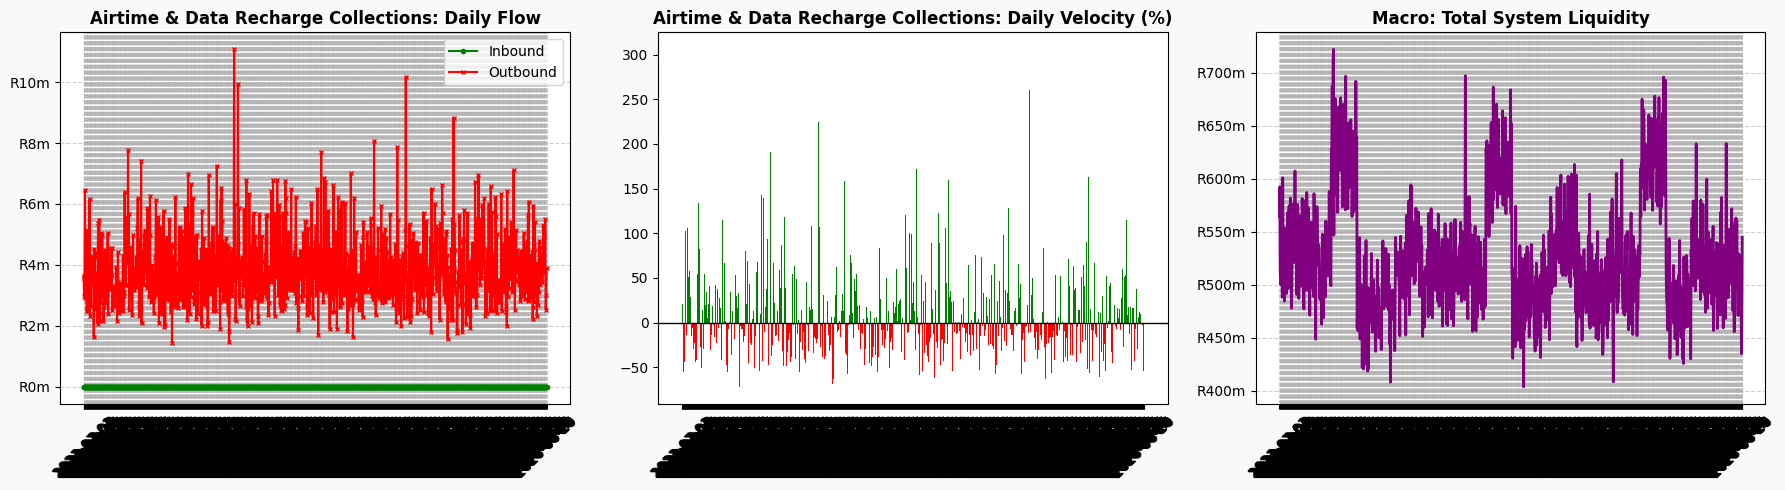

interactive(children=(Dropdown(description='Company:', options=('Airtime & Data Recharge Collections', 'Anchor…

In [5]:
interact(
    display_daily_network_dashboard, 
    company_name=widgets.Dropdown(options=all_entities, value=all_entities[0], description='Company:'),
    target_date=widgets.Dropdown(options=available_dates, value=available_dates[0], description='Date:')
);